# LargeDetune-Phase

* Shape: $\Omega1$ 
* Constants: $\Omega2$, $\Delta1$ and $\Delta2$
* Energy levels: $|0\rangle$, $|1\rangle$, $|r\rangle$ and $|d\rangle$

References:
1. Saffman, M., et al. "Symmetric Rydberg controlled-Z gates with adiabatic pulses." Physical Review A 101.6 (2020): 062309.Saffman, M., et al. "Symmetric Rydberg controlled-Z gates with adiabatic pulses." Physical Review A 101.6 (2020): 062309.

In [1]:
%cd /home/tzuhsuan/doppler_dephasing

/home/tzuhsuan/doppler_dephasing


In [2]:
import os
import glob
import time
from IPython.display import clear_output

from qutip import *
import math

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from rdquantum.pulse_shape import Saffman_shape
from rdquantum.fidelity import fidelity
from rdquantum.optimizer.de import de

# Physical system

In [3]:
### Hamiltonian ###
num_levels = 5    # 0, 1, p, r, d

def Hamiltonian(shape_omega1, value_omega2, value_delta1):
    I = qeye(num_levels)

    H_omega1 = (np.pi) * ( basis(num_levels,2)*basis(num_levels,1).dag() 
                          + basis(num_levels,1)*basis(num_levels,2).dag() )

    # Let Omega2, Delta1 and Delta2 be constants.
    value_delta = value_delta1[0]
    H_omega2 = (np.pi) * value_omega2[0] * ( basis(num_levels,3)*basis(num_levels,2).dag() 
                                            + basis(num_levels,2)*basis(num_levels,3).dag() )
    H_delta1 = (2*np.pi) * value_delta1[0] * ( basis(num_levels,2)*basis(num_levels,2).dag() )
    # H_delta = (2*np.pi) * value_delta * ( basis(num_levels,3)*basis(num_levels,3).dag() )

    B = (2*np.pi * 500)
    # Br = B * ( basis(num_levels,3)*basis(num_levels,3).dag() )
    
    # (MHz) Strength of Rydberg states interaction
    Brr = np.sqrt(B) * ( basis(num_levels,3)*basis(num_levels,3).dag() )
    Brr = tensor(Qobj(Brr), Qobj(Brr))

    H = [[tensor(H_omega1, I) + tensor(I, H_omega1), shape_omega1], 
         [tensor(H_omega2, I) + tensor(I, H_omega2), '1'], 
         [tensor(H_delta1, I) + tensor(I, H_delta1), '1'], 
         # [tensor(H_delta, I) + tensor(I, H_delta), '1'],
         # [tensor(Br, I) + tensor(I, Br), '1'],
         [Brr, '1']]

    return H


### Pulse shape omega1(t), omega2(t) and delta1(t) ###
def PulseShape(times, Pulses, T_gate, n_seg):

    def shape_omega1(t, arg):
        return Saffman_shape(t, Pulses['Omega1'], T_gate, n_seg)

    value_omega2 = Pulses['Omega2']

    value_delta1 = Pulses['Delta1']
    
    # value_delta2 = Pulses['Delta2']
    
    return shape_omega1, value_omega2, value_delta1


### Decay term, c_ops ###
def Decay(gammap=1/0.155, gammar=1/540):
    # gammap: (1/mu s) population decay rate of the Rydberg state
    # gammar: (1/mu s) population decay rate of the P state
    c_ops = []
    I = qeye(num_levels)
    
    # |p>
    L0p = np.sqrt(1/16 * gammap) * ( basis(num_levels,0)*basis(num_levels,2).dag() )
    c_ops.append(tensor(Qobj(L0p), I))
    c_ops.append(tensor(I, Qobj(L0p)))

    L1p = np.sqrt(1/16 * gammap) * ( basis(num_levels,1)*basis(num_levels,2).dag() )
    c_ops.append(tensor(Qobj(L1p), I))
    c_ops.append(tensor(I, Qobj(L1p)))
    
    Ldp = np.sqrt(7/8 * gammap) * ( basis(num_levels,4)*basis(num_levels,2).dag() )
    c_ops.append(tensor(Qobj(Ldp), I))
    c_ops.append(tensor(I, Qobj(Ldp)))
    
    # |r>
    L0r = np.sqrt(1/32 * gammar) * ( basis(num_levels,0)*basis(num_levels,3).dag() )
    c_ops.append(tensor(Qobj(L0r), I))
    c_ops.append(tensor(I, Qobj(L0r)))

    L1r = np.sqrt(1/32 * gammar) * ( basis(num_levels,1)*basis(num_levels,3).dag() )
    c_ops.append(tensor(Qobj(L1r), I))
    c_ops.append(tensor(I, Qobj(L1r)))

    Lpr = np.sqrt(1/2 * gammar) * ( basis(num_levels,2)*basis(num_levels,3).dag() )
    c_ops.append(tensor(Qobj(Lpr), I))
    c_ops.append(tensor(I, Qobj(Lpr)))
    
    Ldr = np.sqrt(7/16 * gammar) * ( basis(num_levels,4)*basis(num_levels,3).dag() )
    c_ops.append(tensor(Qobj(Ldr), I))
    c_ops.append(tensor(I, Qobj(Ldr)))

    return c_ops

# Gate Operation

In [4]:
# Gate operation
def GateOp(Pulses, rho_init, targets):
    T_gate = Pulses['T_gate'][0]    # (mu s) Total gate time
    times = np.linspace(0.0, T_gate, 100)
    n_seg = 2*len(Omega1)   # Number of segments

    shape_omega1, value_omega2, value_delta1 = PulseShape(times, Pulses, T_gate, n_seg)
    H = Hamiltonian(shape_omega1, value_omega2, value_delta1)
    c_ops = Decay(1/0.155, 1/540)
    
    results = mesolve(H, rho_init, times, c_ops, targets
                      , options=Options(nsteps=100000, rhs_reuse=False))
    return results

# Bell fidelity

In [5]:
Had = np.zeros((num_levels,num_levels))
Had[0][0] = 1
Had[0][1] = 1
Had[1][0] = 1
Had[1][1] = -1

I = qeye(num_levels)
Had = Qobj(Had/np.sqrt(2))

ket00 = tensor(basis(num_levels,0), basis(num_levels,0))
ket01 = tensor(basis(num_levels,0), basis(num_levels,1))
ket10 = tensor(basis(num_levels,1), basis(num_levels,0))
ket11 = tensor(basis(num_levels,1), basis(num_levels,1))

# Target Bell state, rho_bell = 1/sqrt(2) * (|01> + |10>)
rho0101 = tensor(I, Had) * ket2dm(ket01) * tensor(I, Had)
rho1010 = tensor(I, Had) * ket2dm(ket10) * tensor(I, Had)
rho0110 = tensor(I, Had) * (ket10 * ket01.dag()) * tensor(I, Had)
rho_bell = [rho0101, rho1010, rho0110]

# Initial state, rhoi = |01><01|
rhoi = tensor(Had, Had) * ket2dm(ket01) * tensor(Had, Had)

bell_fidelity = fidelity(GateOp, rhoi, rho_bell)

# Doppler dephasing

In [7]:
amprange = [1000, 2000, 3000]
Fidelity = []

for i in range(len(amprange)):
    oppulse_file = "data_/erf_{}/out-op_pulse.npz".format(amprange[i])
    oppulse = np.load(oppulse_file, allow_pickle=True)
    
    Omega1 = oppulse['Omega1']
    Omega2 = oppulse['Omega2']
    T_gate = oppulse['T_gate']

    PulsesRange = {'Omega1': [0, 100], 'Omega2': [0, 200], 
                   'Delta1': [0, 1000], 
                   'T_gate': [0, 1]}
    
    # Loop temperature
    Kb = 1.38*10**(-23)   #(m^2 Kg / s^2 K)
    m = 2.2*10**(-25)    #(Kg)
    kp = 1/ (780*10**(-9))  # (1/m)
    T = np.arange(0, 120*10**(6), 20*10**(6))
    fi = []
    for temp in T:
        temp = temp*(10**(-6))
        if temp == 0:
            vrms = 0
        else: 
            vrms = (temp/abs(temp)) * np.sqrt(Kb*np.abs(temp)/m)
        delta_doppler = kp*vrms*(10**(-6))
        Delta1 = oppulse['Delta1'] + delta_doppler

        Pulses = {'Omega1': Omega1, 'Omega2': Omega2, 
                  'Delta1': Delta1, 
                  'T_gate': T_gate}

        fi.append(bell_fidelity.get_fidelity(Pulses))
    Fidelity.append(fi)

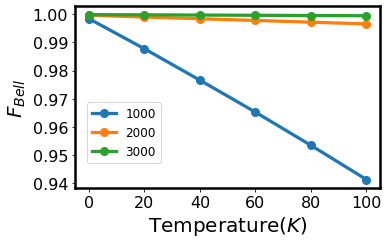

In [10]:
plt.rcParams["figure.figsize"] = [5.5, 3.5]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.linewidth"] = 2.50

fig, ax = plt.subplots()

for i in range(len(amprange)):
    ax.plot(T*(10**(-6)), Fidelity[i], '-o', markersize=8, linewidth=3.25, label=amprange[i])

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax.set_xlabel('Temperature' r'$(K)$', fontsize=20)
ax.set_ylabel(r'$F_{Bell}$', fontsize=20)

plt.yticks(fontsize=16)


# xinterval = np.arange(-2000, 2000, 1000)
# y1interval = np.arange(0.960, 1.005, 0.01)
# ax1.set_xticks(xinterval)
# ax.set_yticks(y1interval)

fig.legend(bbox_to_anchor=(.43, .6), fontsize=12)

In [11]:
Fidelity

[[0.9984081214699667,
  0.987739953836571,
  0.9766012978049412,
  0.9652692650102546,
  0.953506684179998,
  0.9413727064483498],
 [0.999599947857043,
  0.9989835044684298,
  0.9983811079909863,
  0.9977747895828752,
  0.9971638854849438,
  0.996548672088006],
 [0.9998304261308301,
  0.9997670495566691,
  0.9996872082607995,
  0.9996045367304608,
  0.9995203134882087,
  0.999434979551949]]